# Bayesian Lasso in Stan: scale-mixture vs double_exponential

This notebook simulates multivariate regression with some truly zero coefficients, fits Bayesian lasso models in Stan via cmdstanpy, and inspects posterior shrinkage toward zero. The core model we use is the Bayesian lasso implemented through a scale-mixture-of-normals hierarchy, which is mathematically equivalent to placing a Laplace (double-exponential) prior on each coefficient.

## Mathematical model (scale-mixture formulation)
Let $X \in \mathbb{R}^{N\times p}$, $y \in \mathbb{R}^N$, $\beta \in \mathbb{R}^p$, and $\sigma>0$.
- Likelihood:
  $$
  y \mid \beta, \sigma \sim \mathcal{N}(X\beta,\, \sigma^2 I_N).
  $$
- Priors:
  - Noise scale (half-normal via truncation): $\sigma \sim \mathcal{N}(0,1)$ with $\sigma>0$.
  - Global shrinkage (half-Cauchy): $\lambda \sim \text{Half-Cauchy}(0,1)$.
  - Lasso via normal–exponential mixture for each coefficient $j=1,\dots,p$:
    $$
    \beta_j \mid \tau_j \sim \mathcal{N}(0,\, \tau_j), \quad \tau_j \sim \text{Exponential}\!\left(\tfrac{\lambda^2}{2}\right).
    $$

## Equivalence to the Laplace (double-exponential) prior
Marginalizing the local scales $\tau_j$ yields a Laplace prior on $\beta_j$:
$$
\begin{aligned}
 p(\beta_j \mid \lambda)
 &= \int_0^{\infty} \mathcal{N}(\beta_j \mid 0, \tau)\, \text{Exp}\!\left(\tau\,\middle|\, \tfrac{\lambda^2}{2}\right) d\tau \\
 &= \frac{\lambda}{2}\, \exp\big(-\lambda\, |\beta_j|\big),
\end{aligned}
$$
which is the Laplace density with location 0 and scale $b = 1/\lambda$. Equivalently, the log-prior contributes an $\ell_1$ penalty: $\log p(\beta \mid \lambda) \propto -\lambda \sum_j |\beta_j|$.

## Why prefer the scale-mixture form in Stan
- Smooth geometry for HMC/NUTS: the Laplace prior has a cusp at 0 (non-differentiable), whereas the hierarchical normal–exponential form is smooth in $(\beta, \tau)$ and typically reduces divergences.
- Better mixing and adaptivity: local scales $\tau_j$ allow important coefficients to escape heavy shrinkage, while unimportant ones are strongly shrunk.
- Conditional Gaussian convenience: many conditionals are normal, aiding stable inference and diagnostics.
- Flexible hyperpriors: heavy-tailed priors (e.g., half-Cauchy) on the global shrinkage $\lambda$ are straightforward.

## When a direct `double_exponential` is fine
For small problems with mild shrinkage and well-scaled predictors, using Stan’s `double_exponential(0, b)` prior directly on $\beta$ can be sufficient. This notebook also includes a simple variant demonstrating that approach for comparison.

## Bottom line
The hierarchical scale-mixture model is the Bayesian lasso in disguise: it induces the same Laplace prior but tends to sample more efficiently and robustly in Stan. We use both forms here so you can compare behavior and results.

## Mathematical explanation: Bayesian Lasso via scale-mixture-of-normals

Let $X \in \mathbb{R}^{N\times p}$, $y \in \mathbb{R}^N$, $\beta \in \mathbb{R}^p$, and $\sigma>0$. The Bayesian lasso places a Laplace (double-exponential) prior on each coefficient, but here we implement it through an equivalent hierarchical (scale-mixture-of-normals) representation that is more sampler-friendly in Stan.

### Likelihood
$$
y \mid \beta, \sigma \sim \mathcal{N}\!\big(X\beta,\; \sigma^2 I_N\big).
$$

### Priors
- Noise scale (half-normal via truncation): $\sigma \sim \mathcal{N}(0,1)$ with $\sigma>0$.
- Global shrinkage (half-Cauchy): $\lambda \sim \text{Half-Cauchy}(0,1)$.
- Lasso via normal–exponential mixture for $j=1,\dots,p$:
$$
\beta_j \mid \tau_j \sim \mathcal{N}(0,\tau_j), \qquad \tau_j \sim \text{Exponential}\!\left(\tfrac{\lambda^2}{2}\right).
$$

### Equivalence to the Laplace prior
Integrating out the local scale $\tau_j$ yields the Laplace prior on $\beta_j$:
$$
\begin{aligned}
 p(\beta_j \mid \lambda)
 &= \int_0^{\infty} \mathcal{N}(\beta_j\mid 0, \tau)\,\text{Exp}\!\left(\tau\,\middle|\, \tfrac{\lambda^2}{2}\right) d\tau \\
 &= \frac{\lambda}{2}\,\exp\big(-\lambda\,|\beta_j|\big),
\end{aligned}
$$
which is $\text{Laplace}(0, b)$ with $b = 1/\lambda$. Consequently,
$$
\log p(\beta \mid \lambda) \propto -\lambda \sum_{j=1}^p |\beta_j|,
$$
i.e., an $\ell_1$ penalty on coefficients.

### Why this form in Stan?
The Laplace prior has a cusp at 0 (non-differentiable log-density), which can lead to poorer HMC geometry and more divergences. The hierarchical normal–exponential form is smooth in $(\beta,\tau)$, mixes better, and preserves the same marginal Laplace prior on $\beta$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cmdstanpy

np.random.seed(42)

# 1) Simulate data: p predictors, some true zeros
N = 200
p = 10
# True coefficients: 4 non-zero, 6 zeros
beta_true = np.array([1.0, -1.5, 0.0, 0.0, 2.0, 0.0, 0.5, 0.0, 0.0, 0.0])
X = np.random.normal(size=(N, p))
sigma_true = 0.7
y = X @ beta_true + np.random.normal(0, sigma_true, size=N)

data = {
    'N': N,
    'p': p,
    'X': X.tolist(),
    'y': y.tolist()
}

print('True beta:', beta_true)


True beta: [ 1.  -1.5  0.   0.   2.   0.   0.5  0.   0.   0. ]


In [2]:
# 2) Write Stan model implementing Bayesian Lasso via scale mixture of normals
# Laplace prior for beta_j: beta_j ~ Laplace(0, 1/lambda)
# Implemented as: beta_j | tau_j ~ Normal(0, tau_j)
# tau_j ~ Exponential(lambda^2 / 2)  (Park & Casella 2008)
# lambda ~ Half-Cauchy(0, 1) (weakly informative)

stan_code_lasso = r"""
data {
  int<lower=1> N;
  int<lower=1> p;
  matrix[N, p] X;
  vector[N] y;
}
parameters {
  vector[p] beta;
  vector<lower=0>[p] tau;        // local scales for each beta
  real<lower=0> lambda;           // global lasso penalty
  real<lower=0> sigma;            // noise sd
}
model {
  // Likelihood
  y ~ normal(X * beta, sigma);

  // Priors
  sigma ~ normal(0, 1) T[0, ];         // half-normal
  lambda ~ cauchy(0, 1);               // half-Cauchy

  // Scale mixture representation of Laplace
  // beta_j | tau_j ~ Normal(0, tau_j)
  beta ~ normal(0, tau);
  // tau_j ~ Exponential(lambda^2 / 2)
  for (j in 1:p) {
    tau[j] ~ exponential(0.5 * lambda * lambda);
  }
}
"""

# Ensure directory exists before writing
import os
stan_path = os.path.join("./", 'bayesian_lasso.stan')

with open(stan_path, 'w', encoding='utf-8') as f:
    f.write(stan_code_lasso)

print('Stan model written to', stan_path)

Stan model written to ./bayesian_lasso.stan


In [3]:
# 3) Compile and sample
model = cmdstanpy.CmdStanModel(stan_file=stan_path)
fit = model.sample(data=data, seed=2025, chains=4, parallel_chains=4)
print(fit.summary())

# Extract draws
beta_draws = fit.stan_variable('beta')  # shape: (iterations*chains, p)
lambda_draws = fit.stan_variable('lambda')
sigma_draws = fit.stan_variable('sigma')

print('Posterior mean beta:', beta_draws.mean(axis=0))

12:10:28 - cmdstanpy - INFO - compiling stan file C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\bayesian_lasso.stan to exe file C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\bayesian_lasso.exe
12:10:54 - cmdstanpy - INFO - compiled model executable: C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\bayesian_lasso.exe
12:10:54 - cmdstanpy - INFO - compiled model executable: C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\bayesian_lasso.exe
12:10:54 - cmdstanpy - INFO - CmdStan start processing
12:10:54 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:10:54 - cmdstanpy - INFO - CmdStan done processing.
12:10:54 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: exponential_lpdf: Inverse scale parameter is inf, but must be positive finite! (in 'bayesian_lasso.stan', line 27, column 4 to column 48)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bayesian_lasso.stan', line 16, column 2 to column 30)
Exception: normal_lpdf: Scale parameter[7] is 0, but must be positive! (in 'bayesian_lasso.stan', line 24, column 2 to column 24)
Exception: exponential_lpdf: Inverse scale parameter is 0, but must be positive finite! (in 'bayesian_lasso.stan', line 27, column 4 to column 48)
	Exception: exponential_lpdf: Inverse scale parameter is 0, but must be positive finite! (in 'bayesian_lasso.stan', line 27, column 4 to column 48)
	Exception: normal_lpdf: Scale parameter[1] is 0, but must be positive! (in 'bayesian_lasso.stan', line 24, column 2 to column 24)
	Exception: exponential_lpdf: Inverse scale par


               Mean      MCSE    StdDev       MAD         5%        50%  \
lp__     -34.198700  0.112136  3.227050  3.193220 -40.052700 -33.935500   
beta[1]    1.020080  0.005081  0.057536  0.060033   0.925382   1.018580   
beta[2]   -1.428210  0.002744  0.044251  0.047910  -1.501970  -1.428240   
beta[3]   -0.059776  0.001059  0.047003  0.047886  -0.139774  -0.059526   
beta[4]    0.049658  0.002771  0.047234  0.054699  -0.015140   0.046027   
beta[5]    2.015790  0.001167  0.050468  0.047243   1.931150   2.012880   
beta[6]   -0.031866  0.001783  0.043004  0.041386  -0.108916  -0.025909   
beta[7]    0.449770  0.001130  0.047430  0.045545   0.372504   0.451937   
beta[8]   -0.040326  0.001906  0.047714  0.049321  -0.125465  -0.032328   
beta[9]   -0.005652  0.001075  0.043441  0.039504  -0.083314  -0.002267   
beta[10]   0.052135  0.001232  0.046480  0.048451  -0.016082   0.050808   
tau[1]     1.082530  0.030204  0.696985  0.451119   0.425937   0.886105   
tau[2]     1.313030  0.0

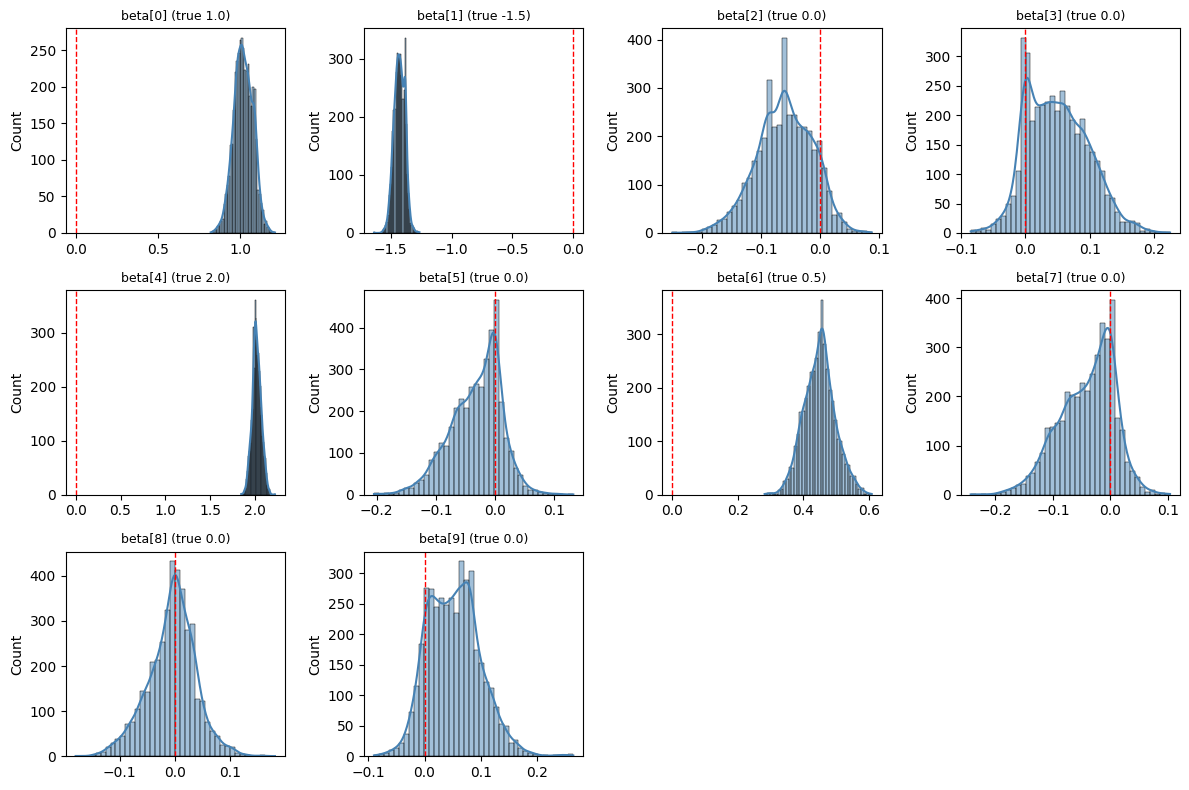

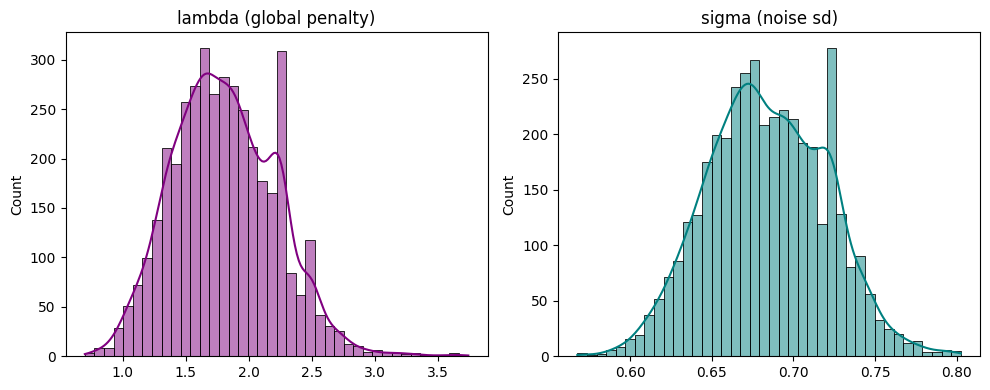

In [4]:
# 4) Posterior histograms for beta coefficients
plt.figure(figsize=(12, 8))
for j in range(p):
    plt.subplot(3, 4, j+1)
    sns.histplot(beta_draws[:, j], bins=40, kde=True, color='steelblue')
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f'beta[{j}] (true {beta_true[j]:.1f})', fontsize=9)
plt.tight_layout()
plt.show()

# Histogram for lambda and sigma
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(lambda_draws, bins=40, kde=True, ax=axs[0], color='purple')
axs[0].set_title('lambda (global penalty)')
sns.histplot(sigma_draws, bins=40, kde=True, ax=axs[1], color='teal')
axs[1].set_title('sigma (noise sd)')
plt.tight_layout()
plt.show()

In [5]:
# 5) Simple performance summary: identify coefficients whose 95% credible interval includes zero
import numpy as np

ci_lower = np.percentile(beta_draws, 2.5, axis=0)
ci_upper = np.percentile(beta_draws, 97.5, axis=0)
shrunk_to_zero = (ci_lower <= 0) & (ci_upper >= 0)

summary_df = pd.DataFrame({
    'beta_true': beta_true,
    'post_mean': beta_draws.mean(axis=0),
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
    'includes_zero': shrunk_to_zero
})
print(summary_df)

n_true_zero = np.sum(beta_true == 0)
n_identified = np.sum(shrunk_to_zero & (beta_true == 0))
print(f"True zeros: {n_true_zero}, correctly identified (CI includes 0): {n_identified}")

   beta_true  post_mean  ci_lower  ci_upper  includes_zero
0        1.0   1.020078  0.909122  1.126564          False
1       -1.5  -1.428213 -1.514821 -1.348758          False
2        0.0  -0.059776 -0.157091  0.023898           True
3        0.0   0.049658 -0.027443  0.145457           True
4        2.0   2.015785  1.917289  2.117331          False
5        0.0  -0.031866 -0.126355  0.041039           True
6        0.5   0.449770  0.358598  0.547845          False
7        0.0  -0.040326 -0.142986  0.038342           True
8        0.0  -0.005652 -0.099978  0.078220           True
9        0.0   0.052135 -0.026538  0.146194           True
True zeros: 6, correctly identified (CI includes 0): 6


In [6]:
# ----



In [7]:
# 6) Add simple Cauchy-prior Stan model at the end and write to file
# This variant uses an unconstrained raw parameter with a simple Cauchy prior
# mapped to a positive global penalty lambda in transformed parameters.

stan_code_lasso_simple = r"""
data {
  int<lower=1> N;
  int<lower=1> p;
  matrix[N, p] X;
  vector[N] y;
}
parameters {
  vector[p] beta;
  vector<lower=0>[p] tau;        // local scales for each beta
  real lambda_raw;                // simple Cauchy prior on raw
  real<lower=0> sigma;            // noise sd
}
transformed parameters {
  real<lower=0> lambda = fabs(lambda_raw); // map raw to positive
}
model {
  // Likelihood
  y ~ normal(X * beta, sigma);

  // Priors
  sigma ~ normal(0, 1) T[0, ];         // half-normal on sigma
  lambda_raw ~ cauchy(0, 1);           // simple Cauchy prior on raw (implies half-Cauchy on lambda)

  // Scale mixture representation of Laplace (Bayesian Lasso)
  beta ~ normal(0, tau);
  for (j in 1:p) {
    tau[j] ~ exponential(0.5 * lambda * lambda);
  }
}
"""

# Write the model to a separate file (does not overwrite earlier one)
import os
stan_path_simple = os.path.join("./", 'bayesian_lasso_simple.stan')
with open(stan_path_simple, 'w', encoding='utf-8') as f:
    f.write(stan_code_lasso_simple)
print('Simple Cauchy-prior Stan model written to', stan_path_simple)

# Optional: compile and run a short sample to verify (commented for speed)
# model_simple = cmdstanpy.CmdStanModel(stan_file=stan_path_simple)
# fit_simple = model_simple.sample(data=data, seed=2025, chains=2, parallel_chains=2, iter_sampling=500, iter_warmup=500)
# print(fit_simple.summary())

Simple Cauchy-prior Stan model written to ./bayesian_lasso_simple.stan


## Simple Bayesian Lasso (double_exponential) with intercept

We add a direct Laplace prior on coefficients using Stan's `double_exponential` with scale `lasso_scale`, an intercept `alpha ~ normal(0, 10)`, and residual scale `sigma_resid ~ normal(0, 5)` (half-normal via positivity constraint). We'll reuse the simulated `X` and `y` from earlier cells and fit this variant for comparison.

In [8]:
# 7) Define Stan model (double_exponential prior) and write to file
# Uses Laplace prior: beta ~ double_exponential(0, lasso_scale)
# Includes intercept alpha and residual sigma_resid

# Hyperparameter for Laplace prior scale (smaller => stronger shrinkage)
lasso_scale = 0.5

stan_code_doubleexp = r"""
data {
  int<lower=1> N;
  int<lower=1> p;
  matrix[N, p] X;
  vector[N] y;
  real<lower=0> lasso_scale; // scale for Laplace prior
}
parameters {
  real alpha;                 // intercept
  vector[p] beta;             // coefficients
  real<lower=0> sigma_resid;  // noise sd
}
model {
  // Priors
  beta ~ double_exponential(0, lasso_scale); // Laplace prior
  alpha ~ normal(0, 10);
  sigma_resid ~ normal(0, 5) T[0, ];         // half-normal via constraint

  // Likelihood
  y ~ normal(alpha + X * beta, sigma_resid);
}
"""

import os
stan_path_doubleexp = os.path.join("./", 'bayesian_lasso_doubleexp.stan')
with open(stan_path_doubleexp, 'w', encoding='utf-8') as f:
    f.write(stan_code_doubleexp)
print('Double-exponential (Laplace) Stan model written to', stan_path_doubleexp)

Double-exponential (Laplace) Stan model written to ./bayesian_lasso_doubleexp.stan


12:10:57 - cmdstanpy - INFO - compiling stan file C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\bayesian_lasso_doubleexp.stan to exe file C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\bayesian_lasso_doubleexp.exe
12:11:21 - cmdstanpy - INFO - compiled model executable: C:\git\Matsuura2022_Bayesian_Statistical_Modeling_with_Stan_R_and_Python\yndk\ch07\bayesian_lasso_doubleexp.exe
12:11:22 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:11:22 - cmdstanpy - INFO - CmdStan done processing.
12:11:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bayesian_lasso_doubleexp.stan', line 21, column 2 to column 44)
Consider re-running with show_console=True if the above output is unclear!
12:11:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bayesian_lasso_doubleexp.stan', line 21, column 2 to column 44)
Consider re-running with show_console=True if the above output is unclear!



                  Mean      MCSE    StdDev       MAD         5%        50%  \
lp__        -32.837500  0.062065  2.542510  2.448440 -37.495200 -32.489400   
alpha        -0.067521  0.000561  0.049011  0.047869  -0.147946  -0.067911   
beta[1]       1.022440  0.000649  0.055388  0.056139   0.932470   1.023140   
beta[2]      -1.428830  0.000497  0.045381  0.046242  -1.504040  -1.428460   
beta[3]      -0.076721  0.000596  0.049955  0.049967  -0.158893  -0.077792   
beta[4]       0.068738  0.000587  0.049229  0.048819  -0.011189   0.068213   
beta[5]       2.024360  0.000574  0.050515  0.050416   1.941840   2.023790   
beta[6]      -0.048675  0.000526  0.047127  0.045464  -0.127920  -0.048218   
beta[7]       0.442489  0.000510  0.048864  0.047499   0.361914   0.443051   
beta[8]      -0.047656  0.000534  0.050416  0.050291  -0.133561  -0.046653   
beta[9]      -0.010752  0.000581  0.053160  0.051704  -0.098608  -0.010783   
beta[10]      0.075258  0.000536  0.047062  0.045750  -0.001494

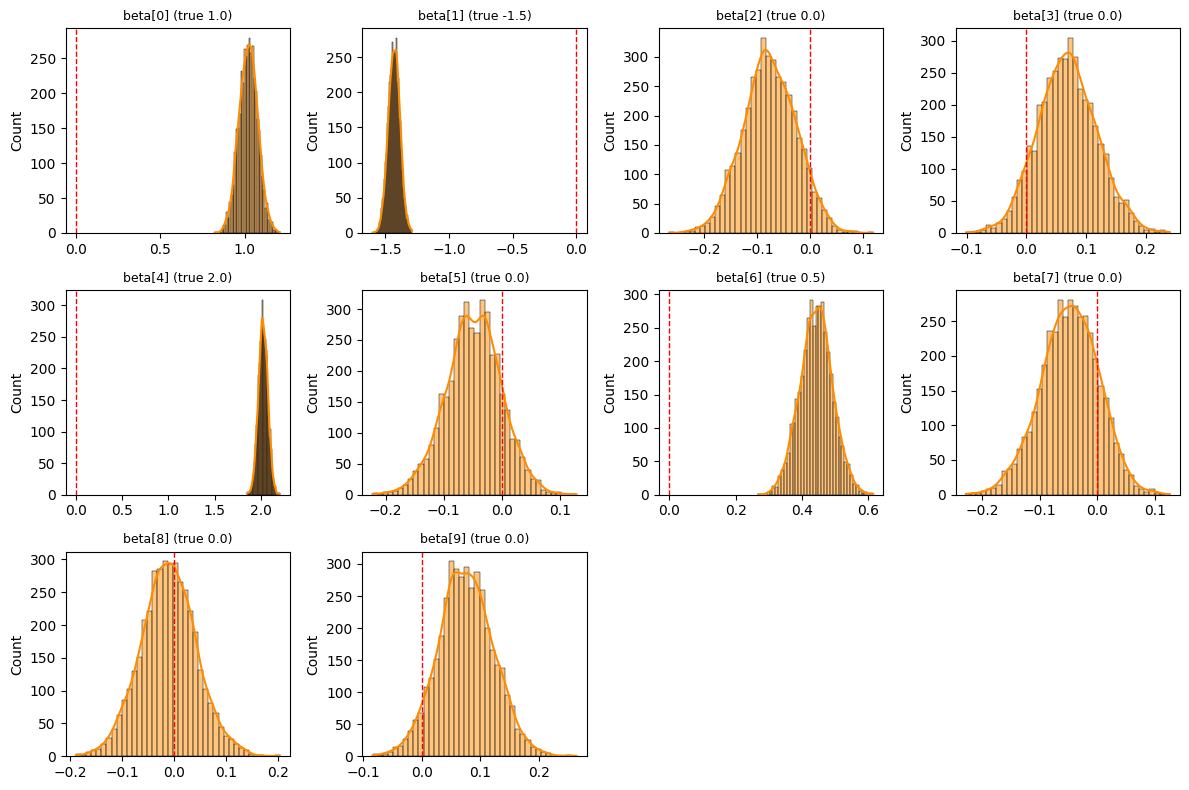

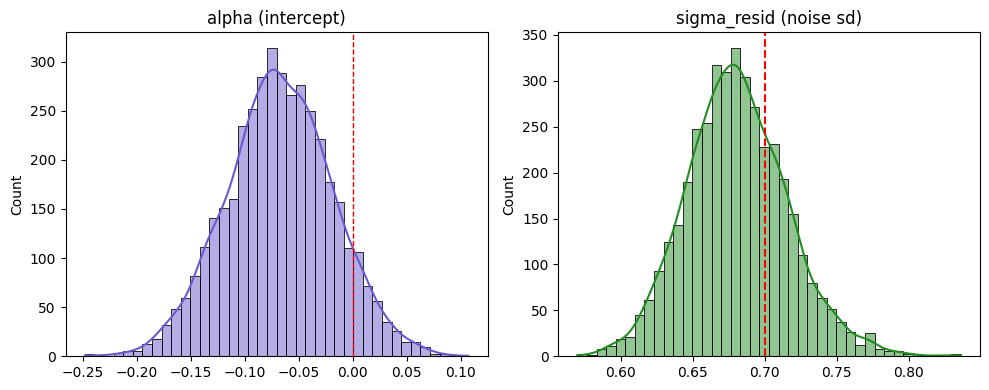

   beta_true  post_mean_de  ci_lower_de  ci_upper_de  includes_zero_de
0        1.0      1.022438     0.914795     1.132421             False
1       -1.5     -1.428829    -1.519411    -1.339639             False
2        0.0     -0.076721    -0.173729     0.020142              True
3        0.0      0.068738    -0.024929     0.168280              True
4        2.0      2.024364     1.926266     2.121568             False
5        0.0     -0.048675    -0.144892     0.042456              True
6        0.5      0.442489     0.345728     0.539521             False
7        0.0     -0.047656    -0.151602     0.046745              True
8        0.0     -0.010752    -0.113941     0.096552              True
9        0.0      0.075258    -0.016726     0.168605              True
[DE] True zeros: 6, correctly identified (CI includes 0): 6


In [9]:
# 8) Compile, sample, and visualize for the double_exponential model
# Reuse previously simulated (N, p, X, y)

# Prepare data including the lasso_scale hyperparameter
data_doubleexp = {
    'N': N,
    'p': p,
    'X': X.tolist(),
    'y': y.tolist(),
    'lasso_scale': float(lasso_scale),
}

# Compile and sample
model_doubleexp = cmdstanpy.CmdStanModel(stan_file=stan_path_doubleexp)
fit_doubleexp = model_doubleexp.sample(data=data_doubleexp, seed=2025, chains=4, parallel_chains=4)
print(fit_doubleexp.summary())

# Extract draws
beta_draws_de = fit_doubleexp.stan_variable('beta')
alpha_draws_de = fit_doubleexp.stan_variable('alpha')
sigma_draws_de = fit_doubleexp.stan_variable('sigma_resid')

print('Posterior mean alpha (DE):', float(alpha_draws_de.mean()))
print('Posterior mean beta (DE):', beta_draws_de.mean(axis=0))
print('Posterior mean sigma_resid (DE):', float(sigma_draws_de.mean()))

# Posterior histograms for coefficients
plt.figure(figsize=(12, 8))
for j in range(p):
    plt.subplot(3, 4, j+1)
    sns.histplot(beta_draws_de[:, j], bins=40, kde=True, color='darkorange')
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f'beta[{j}] (true {beta_true[j]:.1f})', fontsize=9)
plt.tight_layout()
plt.show()

# Histograms for alpha and sigma_resid
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(alpha_draws_de, bins=40, kde=True, ax=axs[0], color='slateblue')
axs[0].axvline(0, color='red', linestyle='--', linewidth=1)
axs[0].set_title('alpha (intercept)')
sns.histplot(sigma_draws_de, bins=40, kde=True, ax=axs[1], color='forestgreen')
axs[1].axvline(sigma_true, color='red', linestyle='--')
axs[1].set_title('sigma_resid (noise sd)')
plt.tight_layout()
plt.show()

# Quick CI-based shrinkage summary
ci_lower_de = np.percentile(beta_draws_de, 2.5, axis=0)
ci_upper_de = np.percentile(beta_draws_de, 97.5, axis=0)
includes_zero_de = (ci_lower_de <= 0) & (ci_upper_de >= 0)

summary_de = pd.DataFrame({
    'beta_true': beta_true,
    'post_mean_de': beta_draws_de.mean(axis=0),
    'ci_lower_de': ci_lower_de,
    'ci_upper_de': ci_upper_de,
    'includes_zero_de': includes_zero_de,
})
print(summary_de)

n_true_zero = np.sum(beta_true == 0)
n_identified_de = np.sum(includes_zero_de & (beta_true == 0))
print(f"[DE] True zeros: {n_true_zero}, correctly identified (CI includes 0): {n_identified_de}")